In [44]:
#автоматическая перезагрузка измененных модулей
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Импорт библиотек и загрузка датасета

In [45]:
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display
from side_lib import *
from visual import *
from phik import phik_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge



pd.set_option('display.float_format', '{:,.2f}'.format) 

In [46]:
data = pd.read_csv('df_train.csv')

In [47]:
#создаем копию для предобработки
df_preprocessed = data.copy()  

### 1. Подготовка данных

#### 1.1 Приведение типов признаков

In [48]:
#изменим формат даты
df_preprocessed['date'] = pd.to_datetime(df_preprocessed['date'], format='%Y-%m-%d')
#удалим дубликаты
df_preprocessed = df_preprocessed.drop_duplicates().reset_index(drop=True)
#преобразуем булевы признаки в числовые
bool_cols = ['has_basement', 'nice_view', 'perfect_condition', 'has_lavatory', 'single_floor', 'renovated']
for col in bool_cols:
    df_preprocessed[col] = df_preprocessed[col].astype(int)


### 1.2 Разделение признаков

In [49]:
bool_features = ['has_basement', 'renovated', 'nice_view', 'perfect_condition', 'single_floor', 'has_lavatory']
num_features = ['bedrooms', 'living_in_m2', 'real_bathrooms']
cat_features = ['month', 'quartile_zone', 'grade']

### 2. Устранение мультиколлинеарности


In [50]:
#вызов функции для расчета VIF
calculate_vif(df_preprocessed)

,feature,VIF
0,living_in_m2,25.79
1,grade,18.39
2,bedrooms,16.34
3,real_bathrooms,13.61
4,quartile_zone,6.24
5,month,4.72
6,has_lavatory,4.10
7,single_floor,2.26
8,has_basement,2.03
9,nice_view,1.15


Столбцы bedrooms, real_bathrooms, living_in_m2, grade имеют сильную мультиколлинеарность.  
Столбцы которые можно обобщить по размеру дома, имеющие мультиколлинеарность приведем в один обший. house_size_score

In [51]:
#создаем новый признак house_size_score как сумму количества спален, ванных комнат и жилой площади в сотнях квадратных метров
house_size_score = df_preprocessed['bedrooms'] + df_preprocessed['real_bathrooms'] + df_preprocessed['living_in_m2']/100
df_preprocessed['house_size_score'] = house_size_score
df_preprocessed.drop(columns=['bedrooms', 'real_bathrooms', 'living_in_m2'], inplace=True)

In [52]:
calculate_vif(df_preprocessed)

,feature,VIF
0,house_size_score,17.08
1,grade,15.98
2,quartile_zone,6.22
3,month,4.68
4,has_lavatory,3.89
5,single_floor,2.06
6,has_basement,1.97
7,nice_view,1.14
8,perfect_condition,1.11
9,renovated,1.05


VIF немного уменьшился, но все еще большой.
Дальнейшее удаление признаков с VIF > 10 (house_size_score или grade) снизит интерпретируемость, потеряется ключевая информацию о размере дома или качестве.  
Это может снизить точность модели, потому что признаки важные

### 3. Feature engineering

Так как мы с X удалим временной признак date по причине того что он datetime, создадим новый набор признаков 

In [53]:
#добавляем признак года продажи
df_preprocessed['year'] = df_preprocessed['date'].dt.year

In [54]:
#выведем информацию о датафрейме после предобработки
df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13601 entries, 0 to 13600
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               13601 non-null  datetime64[ns]
 1   price              13601 non-null  float64       
 2   grade              13601 non-null  int64         
 3   has_basement       13601 non-null  int64         
 4   renovated          13601 non-null  int64         
 5   nice_view          13601 non-null  int64         
 6   perfect_condition  13601 non-null  int64         
 7   has_lavatory       13601 non-null  int64         
 8   single_floor       13601 non-null  int64         
 9   month              13601 non-null  int64         
 10  quartile_zone      13601 non-null  int64         
 11  house_size_score   13601 non-null  float64       
 12  year               13601 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(9)
memory u

### 4. Разобьем данные на признаки и подготовим Pipepline

#### 4.1 Подготовка данных для обучения

Так как распределение цены скошено и имеет длинный правый хвост, нужно будет логарифмировать price.

In [55]:
X = df_preprocessed.drop(columns=['price', 'date'])
y = np.log(df_preprocessed['price'])

Разделим признаки на features по типу

In [56]:
bool_features = ['has_basement', 'renovated', 'nice_view', 'perfect_condition', 'single_floor', 'has_lavatory']
num_features = ['house_size_score', 'year', 'month']
cat_features = ['quartile_zone', 'grade']

#### 4.2 Создание пайплайнов моделей

In [57]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features), 
        ('bool', 'passthrough', bool_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ]
)

In [58]:
pipelines = {
    #Линейная регрессия
    'LinearRegression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]),
    #Дерево решений
    'DecisionTree': Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(random_state=42))
    ]),
    #Случайный лес
    'RandomForest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    #LightGBM
    'LightGBM': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LGBMRegressor(n_estimators=100, random_state=42))
    ])
}


In [59]:
#хранение результатов метрик
model_lr = pipelines['LinearRegression']
model_dt = pipelines['DecisionTree']
model_rf = pipelines['RandomForest']
model_gbm = pipelines['LightGBM']

In [60]:
tscv = TimeSeriesSplit(n_splits=5)

#вывод индексов для каждого фолда
for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    print(f'Fold {fold}:')
    print(f'Train: {train_index[0]}-{train_index[-1]}')
    print(f'Test:  {test_index[0]}-{test_index[-1]}')

Fold 0:
Train: 0-2270
Test:  2271-4536
Fold 1:
Train: 0-4536
Test:  4537-6802
Fold 2:
Train: 0-6802
Test:  6803-9068
Fold 3:
Train: 0-9068
Test:  9069-11334
Fold 4:
Train: 0-11334
Test:  11335-13600


Модель разделит данные на 5 последовательных фолдов

In [61]:
#создаём пустой DataFrame для mean-метрик
df_final = pd.DataFrame()

#список моделей
models = ["LinearRegression", "DecisionTree", "RandomForest", "LightGBM"]

for name in models:
    df_mean, _ = evaluate_pipeline_to_df(
        name, pipelines[name], X, y, tscv,
        plot_residuals=False,
        plot_feature_importance=False,
        show_folds=False
    )
    #добавляем только mean-метрики
    df_final = pd.concat([df_final, df_mean])

#итоговая таблица
df_final


,mean_mae,r2_mean,rmse_mean
LinearRegression,0.17,0.74,0.22


,mean_mae,r2_mean,rmse_mean
DecisionTree,0.24,0.50,0.31


,mean_mae,r2_mean,rmse_mean
RandomForest,0.18,0.72,0.23


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000136 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 297
[LightGBM] [Info] Number of data points in the train set: 2271, number of used features: 16
[LightGBM] [Info] Start training from score 12.976533
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000140 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 297
[LightGBM] [Info] Number of data points in the train set: 4537, number of used features: 16
[LightGBM] [Info] Start training from score 12.979058
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000189 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

/Users/dalgat/Documents/project/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/dalgat/Documents/project/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/dalgat/Documents/project/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000235 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 297
[LightGBM] [Info] Number of data points in the train set: 9069, number of used features: 16
[LightGBM] [Info] Start training from score 12.973908
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000306 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 297
[LightGBM] [Info] Number of data points in the train set: 11335, number of used features: 16
[LightGBM] [Info] Start training from score 12.976273


/Users/dalgat/Documents/project/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/dalgat/Documents/project/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,mean_mae,r2_mean,rmse_mean
LightGBM,0.17,0.75,0.22


,mean_mae,r2_mean,rmse_mean
LinearRegression,0.17,0.74,0.22
DecisionTree,0.24,0.50,0.31
RandomForest,0.18,0.72,0.23
LightGBM,0.17,0.75,0.22


In [62]:
#создаём пустой DataFrame для mean-метрик
df_final = pd.DataFrame()

#список моделей
models = ["LinearRegression", "DecisionTree", "RandomForest", "LightGBM"]

for name in models:
    df_mean, _ = evaluate_pipeline_to_df(
        name, pipelines[name], X, y,
        tscv,
        plot_residuals=False,
        plot_feature_importance=False,
        show_folds=False
    )
    #добавляем только mean-метрики
    df_final = pd.concat([df_final, df_mean])

#итоговая таблица
df_final


,mean_mae,r2_mean,rmse_mean
LinearRegression,0.17,0.74,0.22


,mean_mae,r2_mean,rmse_mean
DecisionTree,0.24,0.50,0.31


,mean_mae,r2_mean,rmse_mean
RandomForest,0.18,0.72,0.23


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000115 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 297
[LightGBM] [Info] Number of data points in the train set: 2271, number of used features: 16
[LightGBM] [Info] Start training from score 12.976533
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 297
[LightGBM] [Info] Number of data points in the train set: 4537, number of used features: 16
[LightGBM] [Info] Start training from score 12.979058
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000201 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

/Users/dalgat/Documents/project/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/dalgat/Documents/project/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/dalgat/Documents/project/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000210 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 297
[LightGBM] [Info] Number of data points in the train set: 9069, number of used features: 16
[LightGBM] [Info] Start training from score 12.973908
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000277 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 297
[LightGBM] [Info] Number of data points in the train set: 11335, number of used features: 16
[LightGBM] [Info] Start training from score 12.976273


/Users/dalgat/Documents/project/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/dalgat/Documents/project/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,mean_mae,r2_mean,rmse_mean
LightGBM,0.17,0.75,0.22


,mean_mae,r2_mean,rmse_mean
LinearRegression,0.17,0.74,0.22
DecisionTree,0.24,0.50,0.31
RandomForest,0.18,0.72,0.23
LightGBM,0.17,0.75,0.22


,mean_mae,r2_mean,rmse_mean
RandomForest,0.18,0.72,0.23


,fold,mae,r2,rmse
0,0,0.18,0.71,0.24
1,1,0.18,0.70,0.24
2,2,0.18,0.71,0.24
3,3,0.17,0.74,0.23
4,4,0.18,0.73,0.23


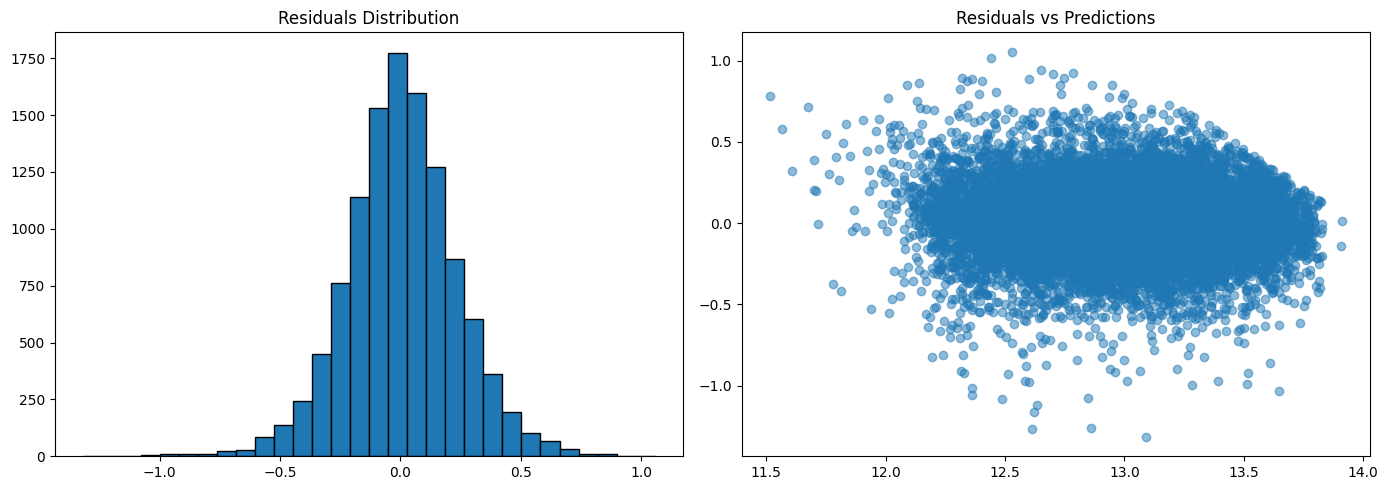

Feature importance недоступна для этой модели


In [66]:
df_res_lr_mean, df_res_lr_folds = evaluate_pipeline_to_df(
    "RandomForest", pipelines['RandomForest'], X, y, tscv
)